In [1]:
#Import pandas to work with data, Matplotlib to plot charts, and Seaborn to make our charts prettier. 
#It’s also common to import NumPy but pandas imports it for us.
#line magic to instruct Jupyter to capture Matplotlib plots and render them in the cell output
%matplotlib inline 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

In [2]:
#Read the csv file, It’s sensible to also do this in a single cell, in case we need to reload it at any point.
#Pandas data structure called DataFrame which basically looks like a table.
df = pd.read_csv('fortune500.csv')

In [3]:
# Check the length of the table and what the tables looks like
#len(df)
# df.tail()

In [4]:
#Rename those columns so we can refer to them later.
df.columns = ['year', 'rank', 'company', 'revenue', 'profit']
#Check data types have been correctly interpreted, the profit type is wrong it should be float64 instead of object
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit      object
dtype: object

In [5]:
#Check if it contains some non-integer values
non_numberic_profits = df.profit.str.contains('[^0-9.-]')
df.loc[non_numberic_profits].head()

,year,rank,company,revenue,profit
228,1955,229,Norton,135.0,N.A.
290,1955,291,Schlitz Brewing,100.0,N.A.
294,1955,295,Pacific Vegetable Oil,97.9,N.A.
296,1955,297,Liebmann Breweries,96.0,N.A.
352,1955,353,Minneapolis-Moline,77.4,N.A.


In [6]:
#Are there any other values except N.A.?
set(df.profit[non_numberic_profits])

{'N.A.'}

In [7]:
#Check how many values are missing
len(df.loc[non_numberic_profits])

369

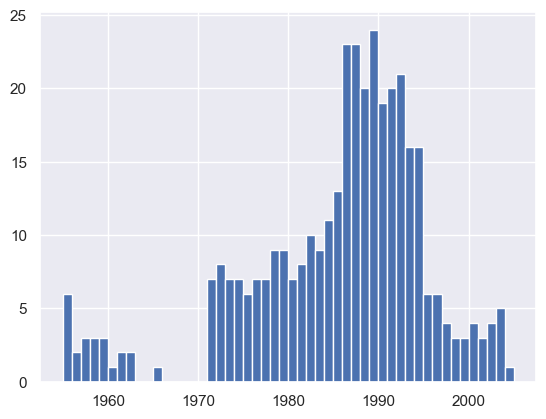

In [8]:
#Let’s have a quick look at the distribution of the None profits
#I'm surprised by the power of the pyplot's function
bin_sizes, _, _ = plt.hist(df.year[non_numberic_profits], bins=range(1955, 2006))

In [9]:
# For our purposes, let’s say this is acceptable and go ahead and remove these rows.
df = df.loc[~non_numberic_profits]
len(df)

25131

In [10]:
# Change the type of profix to float64
df.profit = df.profit.apply(pd.to_numeric)
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit     float64
dtype: object

In [11]:
# pandas.DataFrame.loc: Access a group of rows and columns by label(s) or a boolean array.
# loc[] is primarily label based, but may also be used with a boolean array.
# : in the loc function means the entire column
#df.loc[:, ['year', 'revenue', 'profit']]
group_by_year = df.loc[:, ['year', 'revenue', 'profit']].groupby('year')
#print(group_by_year)

In [12]:
# Return the mean of the values over the requested axis.
avgs = group_by_year.mean()
#print(avgs)

In [13]:
x = avgs.index
y1 = avgs.profit
#print(x)
#print(y1)

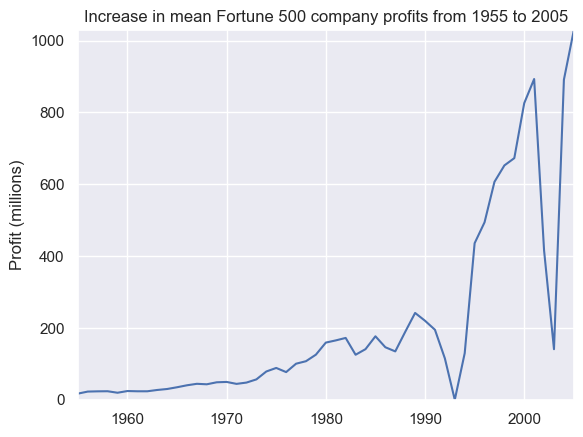

In [14]:
def plot(x, y, ax, title, y_label):
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.plot(x, y)
    ax.margins(x=0, y=0)
fig, ax = plt.subplots()
# print(fig)
# print(ax)
# Show the increase of profits
plot(x, y1, ax, 'Increase in mean Fortune 500 company profits from 1955 to 2005', 'Profit (millions)')

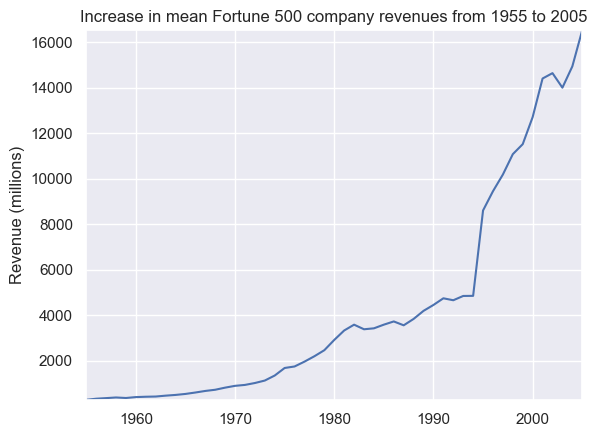

In [15]:
#Show the increase of revenue, the revenue was not badly hit 
y2 = avgs.revenue
# print(y2)
fig, ax = plt.subplots()
plot(x, y2, ax, 'Increase in mean Fortune 500 company revenues from 1955 to 2005', 'Revenue (millions)')

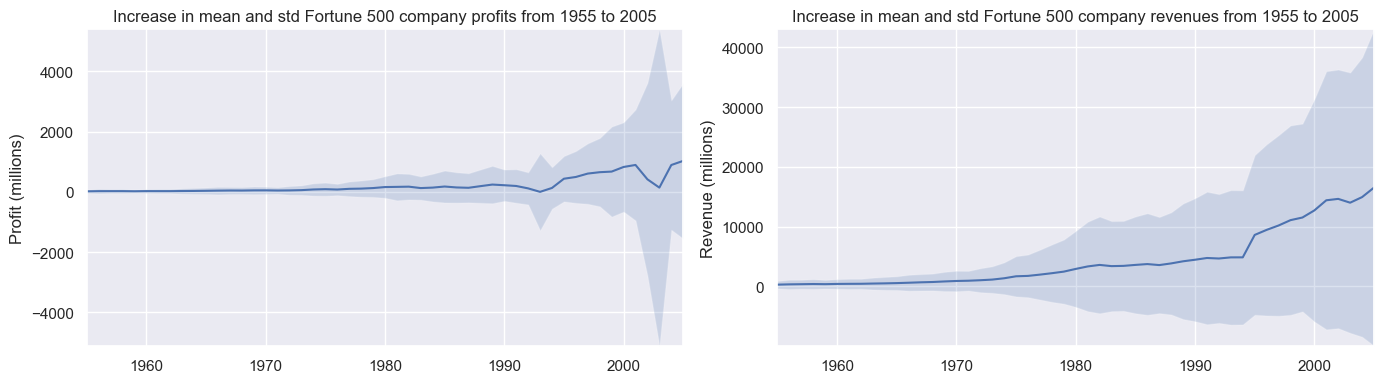

In [16]:
# Superimpose these plots with +/- their standard deviations
def plot_with_std(x, y, stds, ax, title, y_label):
    ax.fill_between(x, y - stds, y + stds, alpha=0.2)
    plot(x, y, ax, title, y_label)
fig, (ax1, ax2) = plt.subplots(ncols=2)
# print(fig)
# print(ax1)
# print(ax2)
title = 'Increase in mean and std Fortune 500 company %s from 1955 to 2005'
stds1 = group_by_year.std().profit.values
stds2 = group_by_year.std().revenue.values
# print(stds1)
# print(stds2)
plot_with_std(x, y1.values, stds1, ax1, title % 'profits', 'Profit (millions)')
plot_with_std(x, y2.values, stds2, ax2, title % 'revenues', 'Revenue (millions)')
fig.set_size_inches(14, 4)
fig.tight_layout()